# Log-Mel Spectrogram & Augmentation Visualisation

Produces thesis figures showing:
1. Drone vs no-drone log-mel spectrograms
2. Each augmentation technique as a separate figure
3. SNR sweep showing noise injection at different levels

All parameters match the training pipeline exactly.
Figures saved to: `/content/drive/MyDrive/drone_audio_processed/figures/`

In [ ]:
!pip -q install datasets librosa matplotlib numpy

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import glob, os, zipfile, requests
from datasets import load_dataset
from google.colab import drive

drive.mount('/content/drive')
OUT_DIR = '/content/drive/MyDrive/drone_audio_processed/figures'
os.makedirs(OUT_DIR, exist_ok=True)

# Parameters matching training pipeline exactly
SR_TARGET  = 16000
WIN_S      = 0.5
N_MELS     = 64
N_FFT      = 512
HOP_LENGTH = 128
FMAX       = 8000
TOP_DB     = 80

FREQ_MASK_MAX    = 8
TIME_MASK_MAX    = 8
MAX_MEL_SHIFT    = 3
MAX_EQ_TILT      = 0.10
MIXUP_ALPHA      = 0.3

DEMAND_DIR         = '/content/DEMAND'
DEMAND_ZENODO_BASE = 'https://zenodo.org/records/1227121/files'
DEMAND_16K_ENVS    = [
    'DKITCHEN','DLIVING','DWASHING','NFIELD','NPARK','NRIVER',
    'OHALLWAY','OMEETING','OOFFICE','PCAFETER','PRESTO','PSTATION',
    'SPSQUARE','STRAFFIC','TBUS','TCAR','TMETRO',
]
SEGMENT_S       = 3.0
MAX_NOISE_CLIPS = 200

rng = np.random.default_rng(42)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})
print('Config loaded.')

Mounted at /content/drive
Config loaded.


In [ ]:
# Helpers

def log_mel_db(y):
    mel = librosa.feature.melspectrogram(
        y=y.astype(np.float32), sr=SR_TARGET, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX, power=2.0
    )
    return librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB).astype(np.float32)

def get_window(sample):
    audio = sample['audio']
    y, sr = np.array(audio['array'], dtype=np.float32), audio['sampling_rate']
    if sr != SR_TARGET:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR_TARGET)
    win = int(WIN_S * SR_TARGET)
    return y[:win] if len(y) >= win else np.pad(y, (0, win - len(y)))

def add_noise(y, noise_bank, snr_db):
    noise = noise_bank[rng.integers(0, len(noise_bank))].copy()
    n = len(y)
    if len(noise) < n:
        noise = np.tile(noise, int(np.ceil(n/len(noise))))
    start = rng.integers(0, len(noise) - n + 1)
    noise = noise[start:start+n]
    p_sig = np.mean(y**2) + 1e-9
    p_noi = np.mean(noise**2) + 1e-9
    noisy = y + np.sqrt(p_sig / (p_noi * 10**(snr_db/10))) * noise
    peak  = np.max(np.abs(noisy))
    return (noisy/peak).astype(np.float32) if peak > 1.0 else noisy

def apply_specaugment(mel):
    mel = mel.copy()
    f = rng.integers(2, FREQ_MASK_MAX); f0 = rng.integers(0, N_MELS-f)
    mel[f0:f0+f, :] = mel.min()
    t = rng.integers(2, TIME_MASK_MAX); t0 = rng.integers(0, mel.shape[1]-t)
    mel[:, t0:t0+t] = mel.min()
    return mel

def apply_time_stretch(y, rate):
    win = int(WIN_S * SR_TARGET)
    s   = librosa.effects.time_stretch(y, rate=rate)
    if len(s) >= win:
        return s[(len(s)-win)//2:(len(s)-win)//2+win]
    return np.pad(s, (0, win-len(s)))

def apply_mel_shift(mel, shift):
    mel = mel.copy()
    fill = np.full((abs(shift), mel.shape[1]), mel.min())
    if shift > 0:
        return np.concatenate([fill, mel[:-shift]], axis=0)
    elif shift < 0:
        return np.concatenate([mel[-shift:], fill], axis=0)
    return mel

def apply_eq_tilt(mel, tilt):
    return mel * (1.0 + np.linspace(-1.0, 1.0, N_MELS) * tilt)[:, None]

def apply_mixup(mel1, mel2, lam):
    return lam * mel1 + (1-lam) * mel2

def show_spec(mel, ax, title):
    img = librosa.display.specshow(
        mel, sr=SR_TARGET, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', fmax=FMAX,
        ax=ax, cmap='magma', vmin=-80, vmax=0
    )
    ax.set_title(title, fontsize=10, fontweight='normal', loc='left', pad=6)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Frequency (Hz)', fontsize=9)
    ax.tick_params(labelsize=8)
    return img

def save_fig(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

print('Helpers defined.')

Helpers defined.


In [ ]:
# Load DEMAND noise bank (identical to training notebooks)

if not os.path.exists(DEMAND_DIR):
    os.makedirs(DEMAND_DIR, exist_ok=True)
    for env in DEMAND_16K_ENVS:
        url = f'{DEMAND_ZENODO_BASE}/{env}_16k.zip?download=1'
        zip_path = f'/content/demand_{env.lower()}.zip'
        print(f'  Downloading {env}...', end=' ', flush=True)
        r = requests.get(url, stream=True); r.raise_for_status()
        with open(zip_path, 'wb') as f:
            for chunk in r.iter_content(1024*1024): f.write(chunk)
        with zipfile.ZipFile(zip_path) as z: z.extractall(DEMAND_DIR)
        os.remove(zip_path)
        print('done')
else:
    print('DEMAND already present.')

demand_wavs = glob.glob(os.path.join(DEMAND_DIR, '**', '*.wav'), recursive=True)
segment_n   = int(SEGMENT_S * SR_TARGET)
noise_bank  = []

for p in rng.permutation(demand_wavs).tolist():
    try:
        y, file_sr = librosa.load(p, sr=None, mono=True)
        if file_sr != SR_TARGET:
            y = librosa.resample(y, orig_sr=file_sr, target_sr=SR_TARGET)
        for start in range(0, len(y)-segment_n+1, segment_n):
            seg = y[start:start+segment_n].astype(np.float32)
            if np.max(np.abs(seg)) > 1e-4:
                noise_bank.append(seg)
        if len(noise_bank) >= MAX_NOISE_CLIPS: break
    except: pass

print(f'Noise bank: {len(noise_bank)} segments loaded.')

Noise bank: 200 segments loaded.


In [ ]:
# Load drone + no-drone windows from DADS

print('Loading DADS...')
ds = load_dataset('geronimobasso/drone-audio-detection-samples', split='train')
all_labels = np.array(ds['label'], dtype=np.int64)

drone_wave = None
nodrone_candidates = []

for sample, label in zip(ds, all_labels):
    if label == 1 and drone_wave is None:
        drone_wave = get_window(sample)
    if label == 0 and len(nodrone_candidates) < 30:
        w = get_window(sample)
        energy = np.mean(w**2)
        nodrone_candidates.append((energy, w))
    if drone_wave is not None and len(nodrone_candidates) >= 30:
        break

nodrone_candidates.sort(key=lambda x: x[0])
nodrone_wave = nodrone_candidates[5][1]

drone_mel   = log_mel_db(drone_wave)
nodrone_mel = log_mel_db(nodrone_wave)
print(f'Log-mel shape: {drone_mel.shape}  |  Input shape (with channel): {drone_mel.shape + (1,)}')


Loading DADS...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

Log-mel shape: (64, 63)  |  Input shape (with channel): (64, 63, 1)


Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig1_drone_vs_nodrone.png


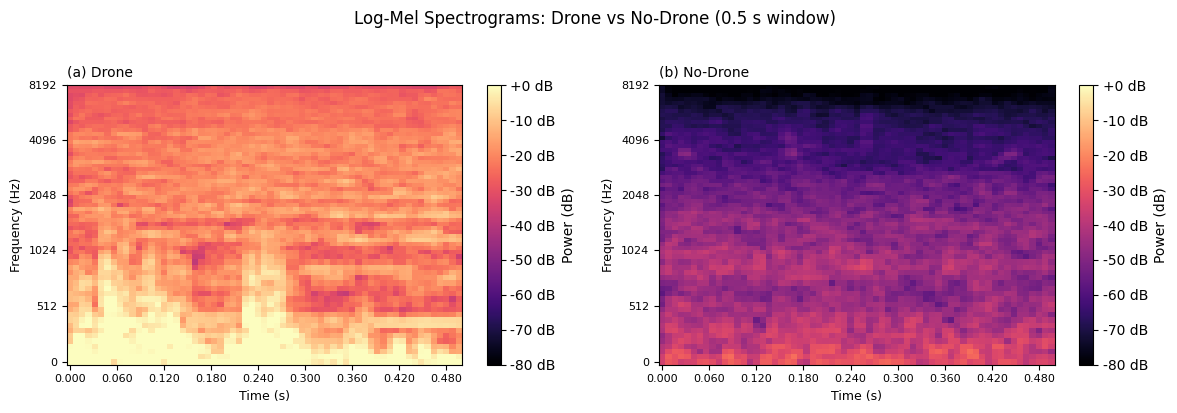

In [ ]:
# Figure 1: Drone vs No-Drone
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mel, title in zip(axes, [drone_mel, nodrone_mel], ['(a) Drone', '(b) No-Drone']):
    img = show_spec(mel, ax, title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Log-Mel Spectrograms: Drone vs No-Drone (0.5 s window)', fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig1_drone_vs_nodrone.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig2_noise_injection.png


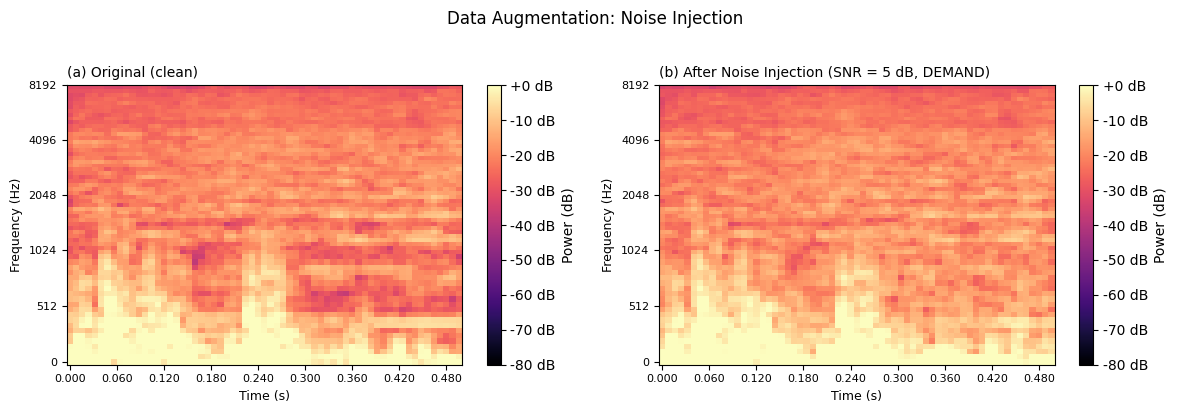

In [ ]:
# Figure 2: Noise Injection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
noisy_mel = log_mel_db(add_noise(drone_wave, noise_bank, snr_db=5.0))
img = show_spec(drone_mel, axes[0], '(a) Original (clean)')
fig.colorbar(img, ax=axes[0], format='%+2.0f dB', label='Power (dB)')
img = show_spec(noisy_mel, axes[1], '(b) After Noise Injection (SNR = 5 dB, DEMAND)')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Data Augmentation: Noise Injection', fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig2_noise_injection.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig3_specaugment.png


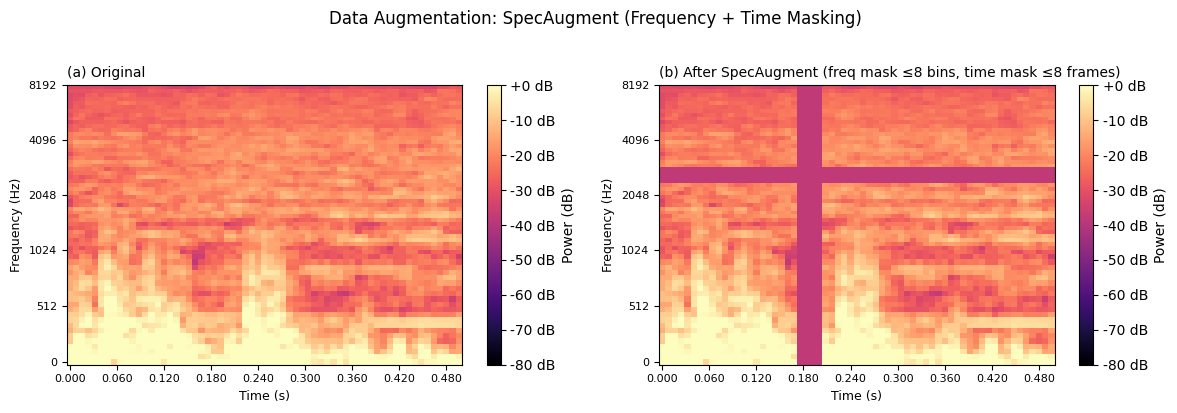

In [ ]:
# Figure 3: SpecAugment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
img = show_spec(drone_mel, axes[0], '(a) Original')
fig.colorbar(img, ax=axes[0], format='%+2.0f dB', label='Power (dB)')
img = show_spec(apply_specaugment(drone_mel), axes[1],
    f'(b) After SpecAugment (freq mask \u2264{FREQ_MASK_MAX} bins, time mask \u2264{TIME_MASK_MAX} frames)')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Data Augmentation: SpecAugment (Frequency + Time Masking)', fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig3_specaugment.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig4_time_stretch.png


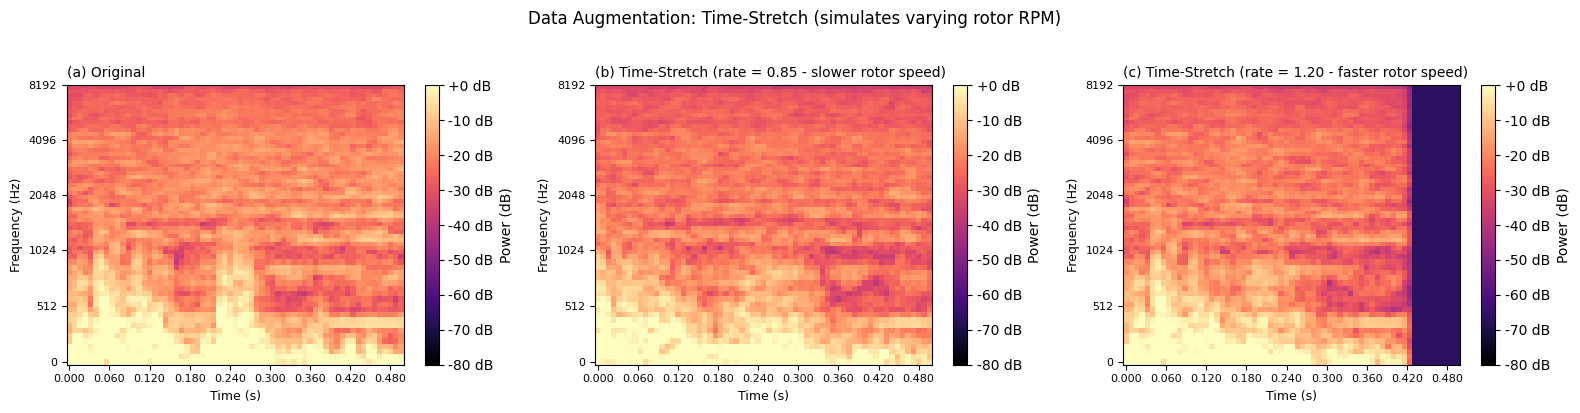

In [ ]:
# Figure 4: Time-Stretch
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (rate, label) in zip(axes, [
    (None, '(a) Original'),
    (0.85, '(b) Time-Stretch (rate = 0.85 - slower rotor speed)'),
    (1.20, '(c) Time-Stretch (rate = 1.20 - faster rotor speed)'),
]):
    mel = drone_mel if rate is None else log_mel_db(apply_time_stretch(drone_wave, rate))
    img = show_spec(mel, ax, label)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Data Augmentation: Time-Stretch (simulates varying rotor RPM)', fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig4_time_stretch.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig5_mel_shift.png


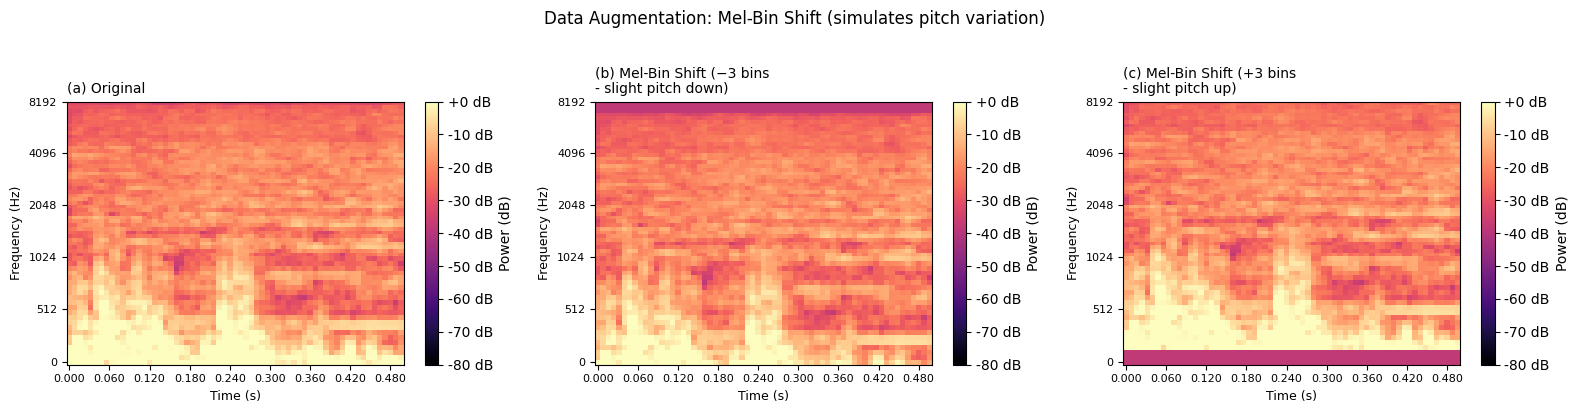

In [ ]:
# Figure 5: Mel-Bin Shift
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (shift, label) in zip(axes, [
    (None, '(a) Original'),
    (-3,   '(b) Mel-Bin Shift (\u22123 bins\n- slight pitch down)'),
    ( 3,   '(c) Mel-Bin Shift (+3 bins\n- slight pitch up)'),
]):
    mel = drone_mel if shift is None else apply_mel_shift(drone_mel, shift)
    img = show_spec(mel, ax, label)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Data Augmentation: Mel-Bin Shift (simulates pitch variation)', fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig5_mel_shift.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig6_eq_tilt.png


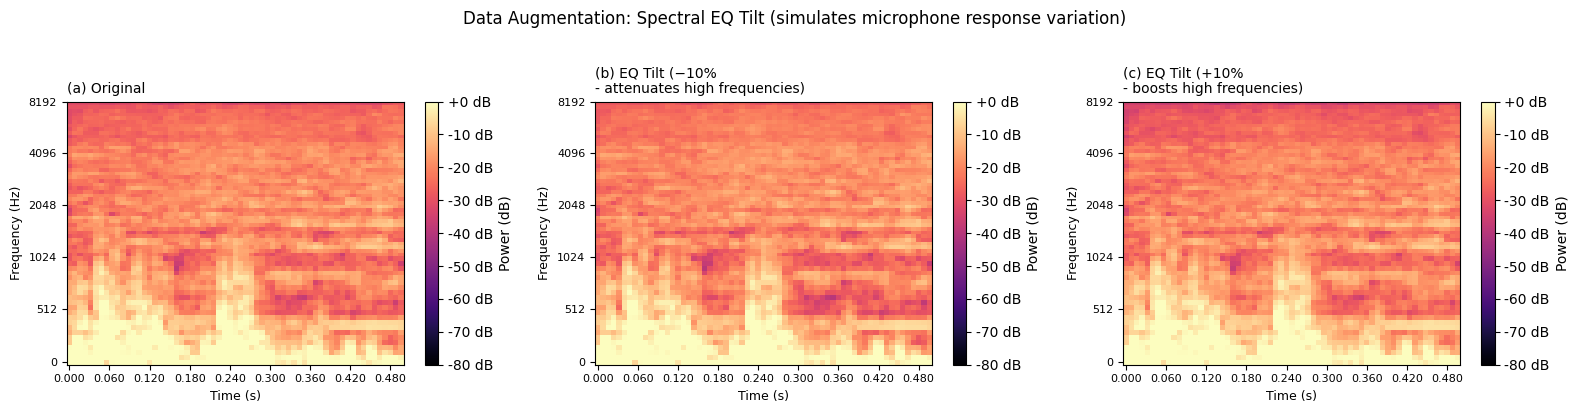

In [ ]:
# Figure 6: EQ Tilt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (tilt, label) in zip(axes, [
    (None,  '(a) Original'),
    (-0.10, '(b) EQ Tilt (\u221210%\n- attenuates high frequencies)'),
    ( 0.10, '(c) EQ Tilt (+10%\n- boosts high frequencies)'),
]):
    mel = drone_mel if tilt is None else apply_eq_tilt(drone_mel, tilt)
    img = show_spec(mel, ax, label)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Data Augmentation: Spectral EQ Tilt (simulates microphone response variation)',
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig6_eq_tilt.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig7_mixup.png


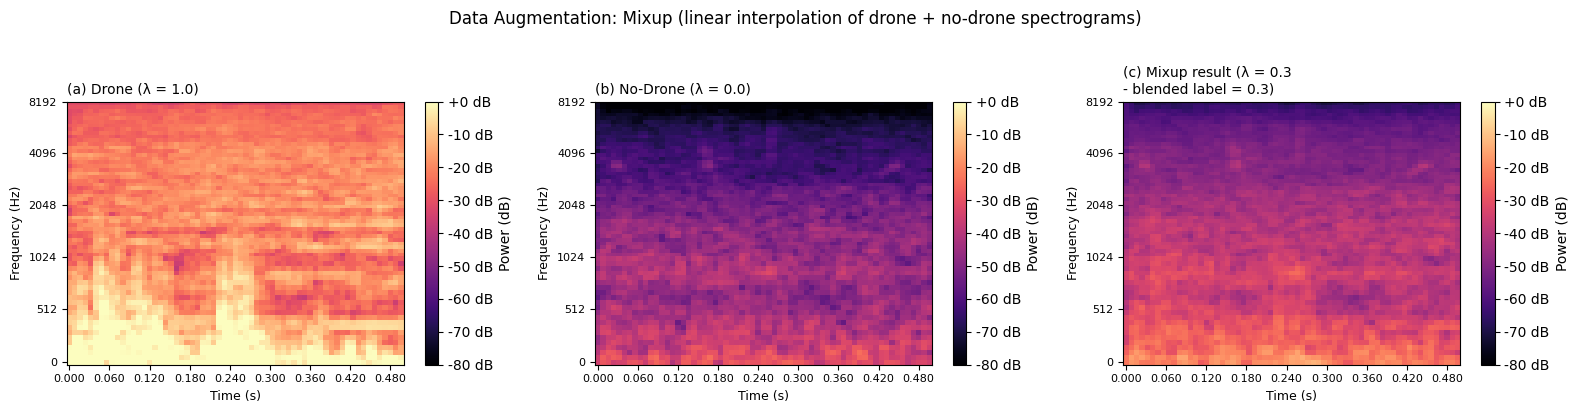

In [ ]:
# Figure 7: Mixup
lam = 0.3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (mel, label) in zip(axes, [
    (drone_mel,                         '(a) Drone (\u03bb = 1.0)'),
    (nodrone_mel,                       '(b) No-Drone (\u03bb = 0.0)'),
    (apply_mixup(drone_mel, nodrone_mel, lam), f'(c) Mixup result (\u03bb = {lam}\n- blended label = {lam})'),
]):
    img = show_spec(mel, ax, label)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
fig.suptitle('Data Augmentation: Mixup (linear interpolation of drone + no-drone spectrograms)',
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig7_mixup.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig8_snr_sweep.png


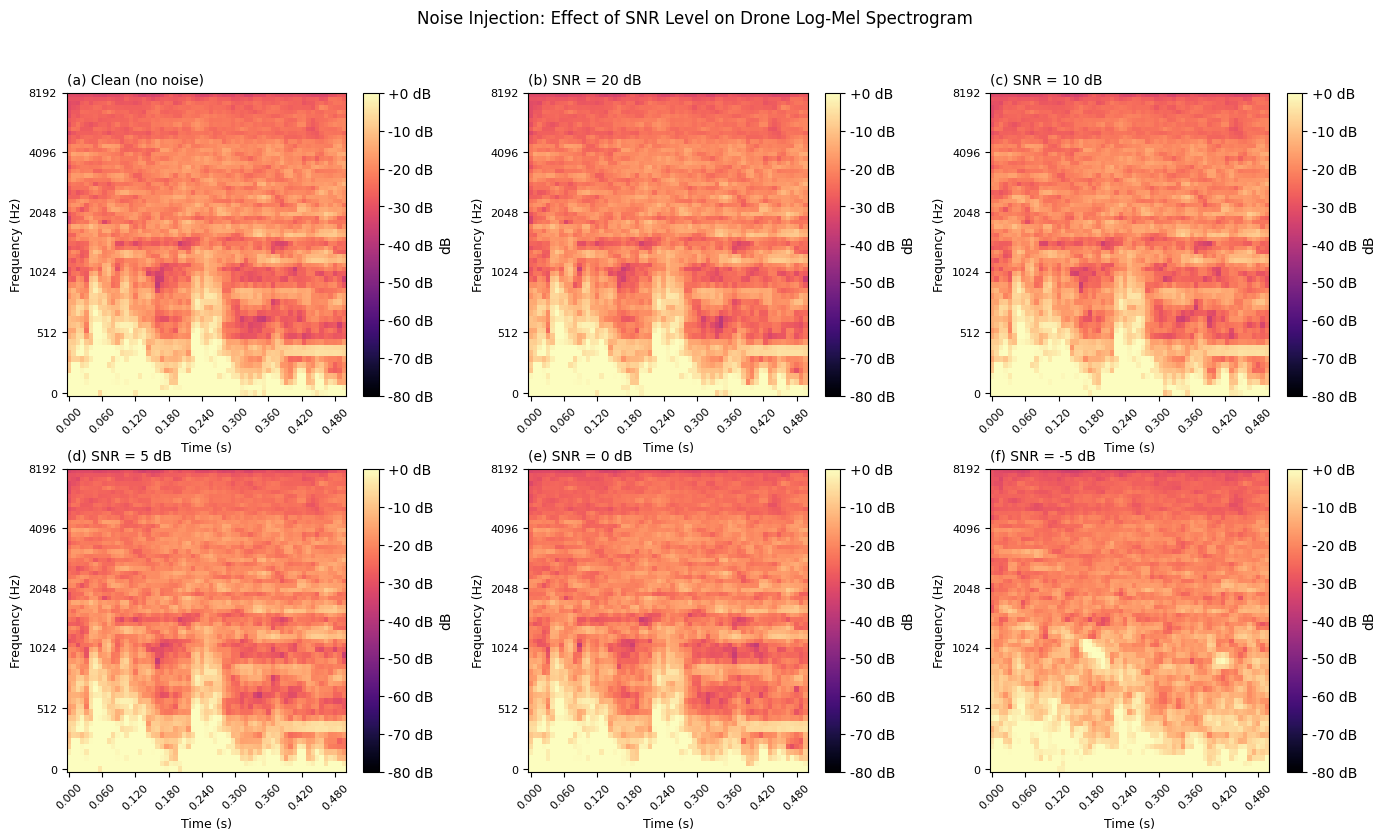

In [ ]:
import matplotlib.pyplot as plt

snr_levels = [20, 10, 5, 0, -5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

img = show_spec(drone_mel, axes_flat[0], '(a) Clean (no noise)')
fig.colorbar(img, ax=axes_flat[0], format='%+2.0f dB', label='dB')

for i, snr in enumerate(snr_levels):
    mel = log_mel_db(add_noise(drone_wave, noise_bank, snr_db=snr))
    img = show_spec(mel, axes_flat[i+1], f'({chr(98+i)}) SNR = {snr} dB')
    fig.colorbar(img, ax=axes_flat[i+1], format='%+2.0f dB', label='dB')

fig.suptitle('Noise Injection: Effect of SNR Level on Drone Log-Mel Spectrogram',
             fontsize=12, y=1.02)
plt.tight_layout()

for ax in axes_flat:
    ax.tick_params(axis='x', rotation=45)

save_fig(fig, 'fig8_snr_sweep.png')
plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig9a_raw_waveform.png


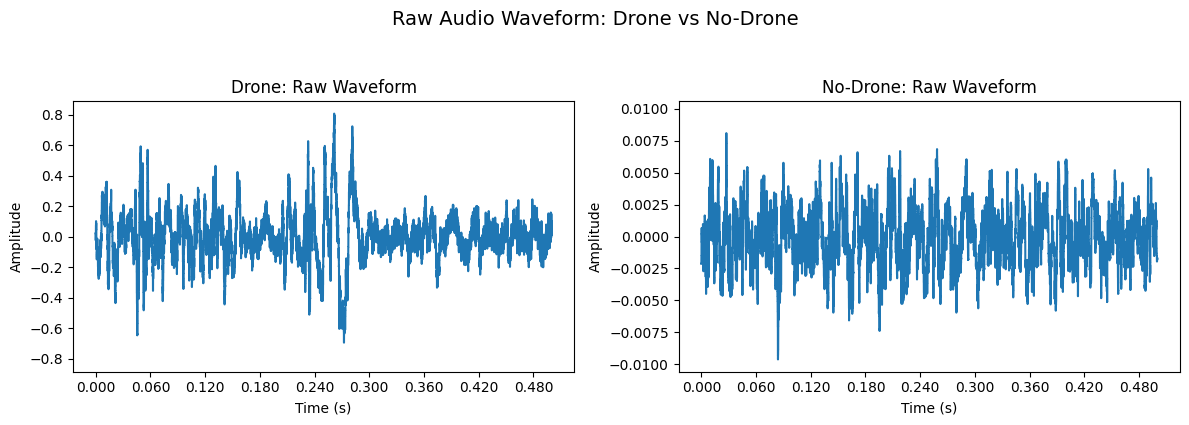

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig9b_stft_spectrogram.png


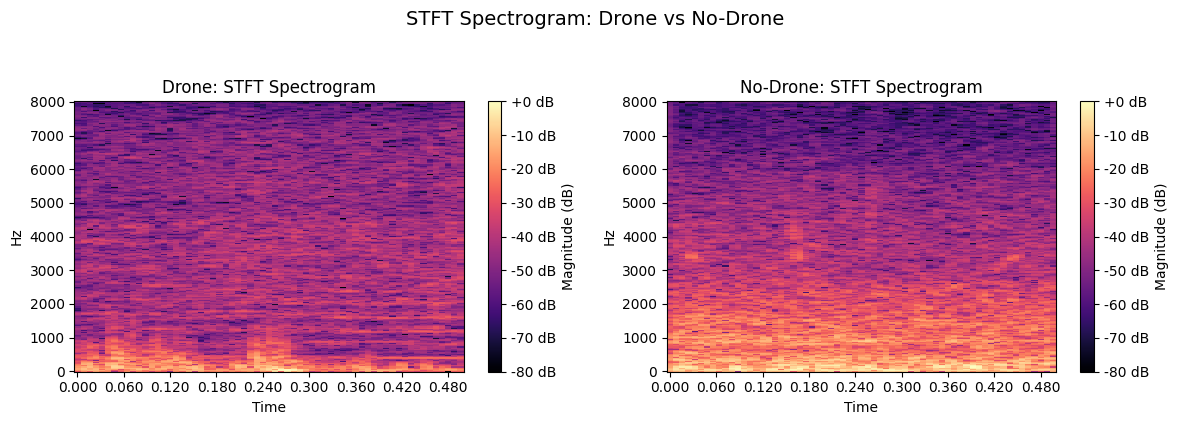

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig9c_mel_spectrogram.png


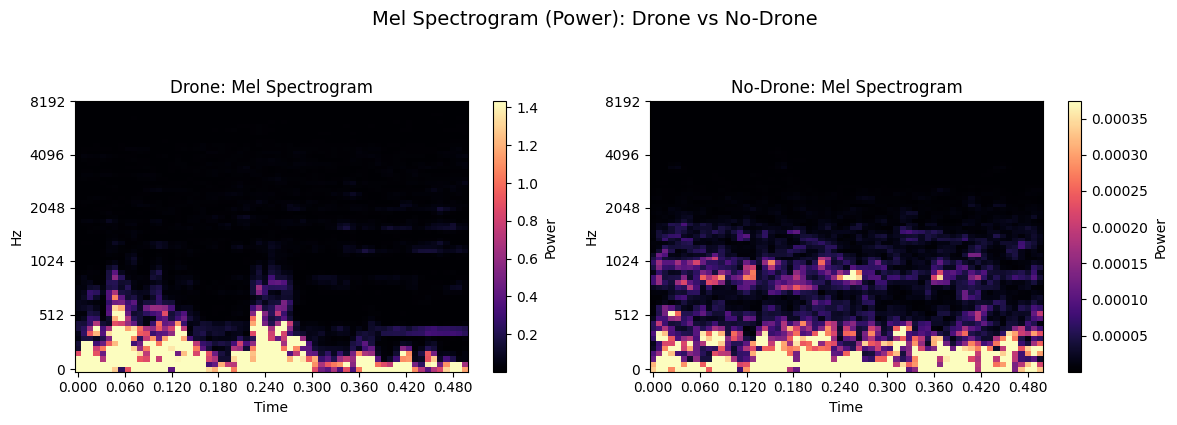

Saved: /content/drive/MyDrive/drone_audio_processed/figures/fig9d_log_mel_spectrogram.png


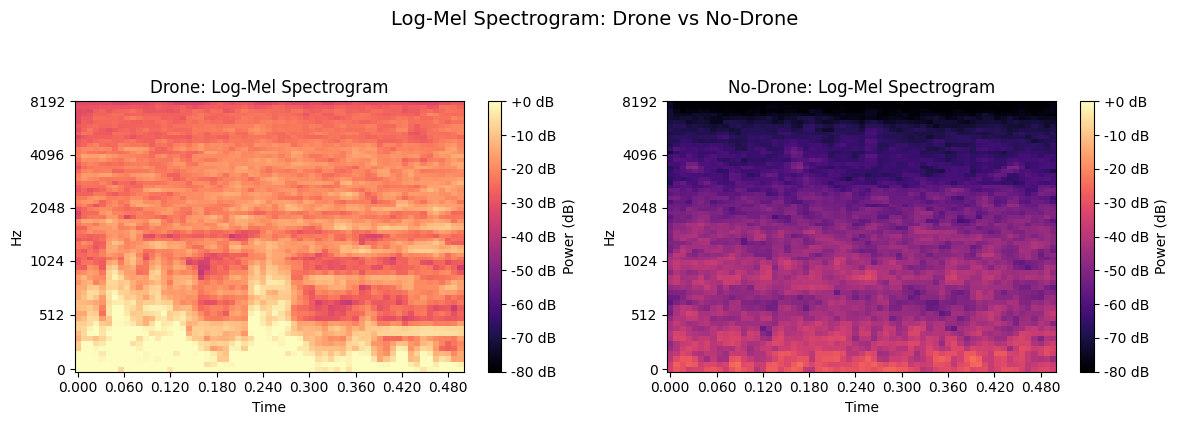

In [32]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

waves = [drone_wave, nodrone_wave]
titles = ['Drone', 'No-Drone']

# --- 1. Raw Waveform ---
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    ax = axes1[i]
    librosa.display.waveshow(waves[i], sr=SR_TARGET, ax=ax)
    ax.set_title(f'{titles[i]}: Raw Waveform')
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Time (s)')
fig1.suptitle('Raw Audio Waveform: Drone vs No-Drone', fontsize=14, y=1.05)
plt.tight_layout()
save_fig(fig1, 'fig9a_raw_waveform.png')
plt.show()

# --- 2. STFT Spectrogram ---
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    ax = axes2[i]
    D = librosa.stft(waves[i], n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(S_db, x_axis='time', y_axis='linear',
                                    sr=SR_TARGET, hop_length=HOP_LENGTH, ax=ax)
    fig2.colorbar(img1, ax=ax, format="%+2.0f dB", label='Magnitude (dB)')
    ax.set_title(f'{titles[i]}: STFT Spectrogram')
fig2.suptitle('STFT Spectrogram: Drone vs No-Drone', fontsize=14, y=1.05)
plt.tight_layout()
save_fig(fig2, 'fig9b_stft_spectrogram.png')
plt.show()

# --- 3. Mel Spectrogram (Power) ---
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
mels = [librosa.feature.melspectrogram(y=w, sr=SR_TARGET, n_fft=N_FFT,
                                       hop_length=HOP_LENGTH, n_mels=N_MELS, fmax=FMAX) for w in waves]

for i in range(2):
    ax = axes3[i]
    # Calculate percentiles for each individual spectrogram to optimize contrast
    vmin = np.percentile(mels[i], 5)
    vmax = np.percentile(mels[i], 95)

    img2 = librosa.display.specshow(mels[i], x_axis='time', y_axis='mel',
                                    sr=SR_TARGET, hop_length=HOP_LENGTH, fmax=FMAX,
                                    ax=ax, vmin=vmin, vmax=vmax)
    fig3.colorbar(img2, ax=ax, label='Power')
    ax.set_title(f'{titles[i]}: Mel Spectrogram')
fig3.suptitle('Mel Spectrogram (Power): Drone vs No-Drone', fontsize=14, y=1.05)
plt.tight_layout()
save_fig(fig3, 'fig9c_mel_spectrogram.png')
plt.show()

# --- 4. Final Log-Mel Spectrogram (dB) ---
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    ax = axes4[i]
    mel = librosa.feature.melspectrogram(y=waves[i], sr=SR_TARGET, n_fft=N_FFT,
                                         hop_length=HOP_LENGTH, n_mels=N_MELS, fmax=FMAX)
    log_mel = librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB)
    img3 = librosa.display.specshow(log_mel, x_axis='time', y_axis='mel',
                                    sr=SR_TARGET, hop_length=HOP_LENGTH, fmax=FMAX, ax=ax,
                                    cmap='magma', vmin=-80, vmax=0)
    fig4.colorbar(img3, ax=ax, format="%+2.0f dB", label='Power (dB)')
    ax.set_title(f'{titles[i]}: Log-Mel Spectrogram')
fig4.suptitle('Log-Mel Spectrogram: Drone vs No-Drone', fontsize=14, y=1.05)
plt.tight_layout()
save_fig(fig4, 'fig9d_log_mel_spectrogram.png')
plt.show()